# Greenhouse Hiring Data Pipeline
### Lloyds BCB 毕设项目 — Growth Signal 获取链路

**目标**：从公司主表出发，通过 Greenhouse Jobs Board API 批量获取招聘数据，聚合为 `hiring_growth_score` 特征，供最终Score评估。

**流程**：
```
company_master.csv
      ↓
Step 1: 公司名 → Slug 候选生成
      ↓
Step 2: Greenhouse API 验证 slug 是否存在
      ↓
Step 3: 批量拉取招聘职位数据
      ↓
Step 4: 聚合成 Growth Signal 特征表
      ↓
hiring_signals.csv  →  Opportunity Score 模型
```

In [2]:
import re
import time
import logging
import requests
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
from tqdm.notebook import tqdm

# 日志配置
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger(__name__)

## 1. 配置参数

根据你的实际情况修改以下路径和参数。

In [9]:
# ─── 路径配置 ───────────────────────────────────────────
INPUT_PATH  = "../output/UKcompanies_8_sectors_cleaned.csv"  
OUTPUT_DIR  = Path("../output")
SLUG_MAP_PATH  = OUTPUT_DIR / "greenhouse_slug_map.csv"
JOBS_RAW_PATH  = OUTPUT_DIR / "greenhouse_jobs_raw.csv"
SIGNALS_PATH   = OUTPUT_DIR / "hiring_signals.csv"

# ─── API 配置 ────────────────────────────────────────────
GREENHOUSE_URL   = "https://boards-api.greenhouse.io/v1/boards/{slug}/jobs"
REQUEST_TIMEOUT  = 10     # 秒
SLUG_GUESS_DELAY = 0.3    # 猜 slug 时每次请求间隔（秒）
JOBS_FETCH_DELAY = 1.0    # 拉招聘数据时每次请求间隔（秒）
MAX_SLUG_CANDS   = 3      # 每家公司最多尝试几个 slug 候选

print("✓ 配置完成")
print(f"  输入文件: {INPUT_PATH}")
print(f"  输出目录: {OUTPUT_DIR.resolve()}")

✓ 配置完成
  输入文件: ../output/UKcompanies_8_sectors_cleaned.csv
  输出目录: /Users/lr/Desktop/DS_Group/UoB_DS_GroupProject_Team6_LloydsBank/output


## 2. 读取公司主表

过滤条件：仅保留英国本土（`is_uk_company == True`）的活跃公司（`CompanyStatus == 'Active'`）。

In [4]:
master = pd.read_csv(INPUT_PATH, low_memory=False)
print(f"原始记录数: {len(master):,}")

# 过滤活跃英国公司
if 'is_uk_company' in master.columns:
    master = master[master['is_uk_company'] == True]
if 'CompanyStatus' in master.columns:
    master = master[master['CompanyStatus'] == 'Active']

print(f"过滤后记录数: {len(master):,}")
master[['CompanyNumber', 'CompanyName', 'sector_id', 'CompanyStatus']].head(10)

原始记录数: 3,415,689
过滤后记录数: 3,152,288


,CompanyNumber,CompanyName,sector_id,CompanyStatus
0,00000086,KENTSTONE PROPERTIES LIMITED,4.0,Active
1,00000118,ASHFORD CATTLE MARKET COMPANY LIMITED(THE),3.0,Active
2,00000121,"ORIENTAL GAS COMPANY, LIMITED(THE)",5.0,Active
3,00000140,N & C BUILDING PRODUCTS LIMITED,2.0,Active
4,00000295,METHODIST NEWSPAPER COMPANY LIMITED,5.0,Active
5,00000371,LONDON AND SUBURBAN LAND AND BUILDING COMPANY ...,5.0,Active
6,00000452,VERNON INVESTMENTS (1856) LIMITED,4.0,Active
7,00000537,REIGATE INVESTMENT COMPANY LIMITED (THE),4.0,Active
8,00000687,BRITISH INDIAN TEA COMPANY LIMITED,5.0,Active
9,00000866,STAVELEY INDUSTRIES LIMITED,5.0,Active


In [14]:
# ── 分层抽样：每个 sector 取 100 家 ──────────────────────────
SAMPLE_PER_SECTOR = 100
RANDOM_SEED       = 42   # 固定随机种子，保证结果可复现

# 检查 sector_id 字段是否存在
assert 'sector_id' in master.columns, "主表中没有 sector_id 字段，请先完成行业标注"

before = len(master)

master = (
    master
    .groupby('sector_id', group_keys=False)
    .apply(lambda g: g.sample(
        n=min(SAMPLE_PER_SECTOR, len(g)),  # 不足100家的sector全取
        random_state=RANDOM_SEED
    ))
    .reset_index(drop=True)
)

print(f"抽样前: {before:,} 家")
print(f"抽样后: {len(master):,} 家")
print()
print("各 sector 样本数：")
print(master['sector_id'].value_counts().sort_index().to_string())

抽样前: 3,152,288 家
抽样后: 800 家

各 sector 样本数：
sector_id
1.0    100
2.0    100
3.0    100
4.0    100
5.0    100
6.0    100
7.0    100
8.0    100


/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_58318/116493573.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


## 3. Step 1 — 公司名 → Slug 候选生成

Greenhouse 的 slug 是公司在其招聘平台上的唯一标识，例如：
- `https://boards.greenhouse.io/monzo` → slug = `monzo`
- `https://boards.greenhouse.io/revolut` → slug = `revolut`

由于没有官方映射表，通过公司名规则生成候选 slug，再用 API 验证。

In [16]:
# 清洗时需要去掉的常见英国公司名后缀
SUFFIXES_TO_STRIP = [
    r'\blimited\b', r'\bltd\b',   r'\bplc\b',      r'\bllp\b',
    r'\blp\b',      r'\bgroup\b', r'\bholdings\b', r'\buk\b',
    r'\binternational\b', r'\bglobal\b', r'\bservices\b',
    r'\bsolutions\b', r'\btechnologies\b', r'\btech\b',
]

def clean_company_name(name: str) -> str:
    """标准化公司名称：小写、去域名后缀、去公司类型后缀、去标点"""
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    # 去掉 .com / .co.uk / .io 等域名后缀
    name = re.sub(r'\.com\b|\.co\.uk\b|\.io\b|\.ai\b', '', name)
    for suffix in SUFFIXES_TO_STRIP:
        name = re.sub(suffix, '', name).strip()
    name = re.sub(r'\s+', ' ', name).strip()
    return name


def generate_slug_candidates(company_name: str) -> list:
    """
    生成最多 MAX_SLUG_CANDS 个候选 slug

    候选1 — 去掉所有非字母数字（最常见格式，如 monzobank）
    候选2 — 空格替换为连字符（如 monzo-bank）
    候选3 — 只取第一个词（如 monzo）
    """
    cleaned = clean_company_name(company_name)
    if not cleaned:
        return []

    c1 = re.sub(r'[^a-z0-9]', '',  cleaned)
    c2 = re.sub(r'[^a-z0-9]', '-', cleaned).strip('-')
    c3 = re.sub(r'[^a-z0-9]', '',  cleaned.split()[0]) if cleaned.split() else ''

    seen, candidates = set(), []
    for c in [c1, c2, c3]:
        if c and c not in seen and len(c) >= 2:
            seen.add(c)
            candidates.append(c)

    return candidates[:MAX_SLUG_CANDS]


# ── 快速测试 ──
test_names = [
    "Monzo Bank Limited",
    "Revolut Ltd",
    "Deliveroo PLC",
    "ASOS.com Limited",
    "Rolls-Royce Holdings PLC",
    "Some Random Company Ltd",
]

print(f"{'公司名':<40} {'Slug 候选'}")
print("-" * 70)
for name in test_names:
    print(f"{name:<40} {generate_slug_candidates(name)}")

公司名                                      Slug 候选
----------------------------------------------------------------------
Monzo Bank Limited                       ['monzobank', 'monzo-bank', 'monzo']
Revolut Ltd                              ['revolut']
Deliveroo PLC                            ['deliveroo']
ASOS.com Limited                         ['asos']
Rolls-Royce Holdings PLC                 ['rollsroyce', 'rolls-royce']
Some Random Company Ltd                  ['somerandomcompany', 'some-random-company', 'some']


## 4. Step 2 — 验证 Slug 并建立映射表

逐家公司尝试所有候选 slug，通过 Greenhouse API 验证是否真实存在。

**支持断点续跑**：如果中途中断，重新运行此 cell 会自动跳过已处理的公司。

In [17]:
def verify_greenhouse_slug(slug: str) -> bool:
    """向 Greenhouse API 发请求，200 = slug 存在"""
    try:
        resp = requests.get(
            GREENHOUSE_URL.format(slug=slug),
            timeout=REQUEST_TIMEOUT
        )
        return resp.status_code == 200
    except requests.RequestException:
        return False


def find_slug_for_company(company_number: str, company_name: str) -> dict:
    """尝试所有候选，返回第一个验证成功的 slug"""
    candidates = generate_slug_candidates(company_name)
    result = {
        'CompanyNumber': company_number,
        'CompanyName':   company_name,
        'gh_slug':       None,
        'slug_source':   None,
        'gh_found':      False,
    }
    for i, slug in enumerate(candidates, start=1):
        if verify_greenhouse_slug(slug):
            result.update({'gh_slug': slug, 'slug_source': f'candidate_{i}', 'gh_found': True})
            break
        time.sleep(SLUG_GUESS_DELAY)
    return result



In [18]:
companies = master[['CompanyNumber', 'CompanyName']].drop_duplicates().reset_index(drop=True)

# 断点续跑：跳过已处理的公司
if SLUG_MAP_PATH.exists():
    done = set(pd.read_csv(SLUG_MAP_PATH)['CompanyNumber'].astype(str))
    companies = companies[~companies['CompanyNumber'].astype(str).isin(done)]
    print(f"断点续跑：跳过已处理 {len(done):,} 家，剩余 {len(companies):,} 家")
else:
    print(f"全新开始，共 {len(companies):,} 家公司待处理")

# ── 开始 Slug 发现 ──
batch = []
for _, row in tqdm(companies.iterrows(), total=len(companies), desc="Slug discovery"):
    batch.append(find_slug_for_company(str(row['CompanyNumber']), str(row['CompanyName'])))

    if len(batch) % 100 == 0:
        pd.DataFrame(batch).to_csv(
            SLUG_MAP_PATH, mode='a',
            header=not SLUG_MAP_PATH.exists(), index=False
        )
        batch = []

if batch:
    pd.DataFrame(batch).to_csv(
        SLUG_MAP_PATH, mode='a',
        header=not SLUG_MAP_PATH.exists(), index=False
    )

print("Slug 发现完成，结果已保存至:", SLUG_MAP_PATH)

断点续跑：跳过已处理 100 家，剩余 800 家


Slug discovery:   0%|          | 0/800 [00:00<?, ?it/s]

Slug 发现完成，结果已保存至: ../output/greenhouse_slug_map.csv


In [19]:
# ── 结果统计 ──
slug_map = pd.read_csv(SLUG_MAP_PATH)
found    = slug_map[slug_map['gh_found'] == True]
total    = len(slug_map)

print(f"总处理公司数:          {total:,}")
print(f"找到 Greenhouse slug:  {len(found):,}  ({len(found)/total*100:.1f}%)")
print(f"未找到:                {total - len(found):,}  ({(total-len(found))/total*100:.1f}%)")
print()
print("Slug 来源分布（candidate_1 = 第一个候选直接命中）：")
print(found['slug_source'].value_counts().to_string())
print()
slug_map.head(10)

总处理公司数:          900
找到 Greenhouse slug:  37  (4.1%)
未找到:                863  (95.9%)

Slug 来源分布（candidate_1 = 第一个候选直接命中）：
slug_source
candidate_3    35
candidate_1     2



,CompanyNumber,CompanyName,gh_slug,slug_source,gh_found
0,00000086,KENTSTONE PROPERTIES LIMITED,NaN,NaN,False
1,00000118,ASHFORD CATTLE MARKET COMPANY LIMITED(THE),NaN,NaN,False
2,00000121,"ORIENTAL GAS COMPANY, LIMITED(THE)",NaN,NaN,False
3,00000140,N & C BUILDING PRODUCTS LIMITED,NaN,NaN,False
4,00000295,METHODIST NEWSPAPER COMPANY LIMITED,NaN,NaN,False
5,00000371,LONDON AND SUBURBAN LAND AND BUILDING COMPANY ...,london,candidate_3,True
6,00000452,VERNON INVESTMENTS (1856) LIMITED,NaN,NaN,False
7,00000537,REIGATE INVESTMENT COMPANY LIMITED (THE),NaN,NaN,False
8,00000687,BRITISH INDIAN TEA COMPANY LIMITED,NaN,NaN,False
9,00000866,STAVELEY INDUSTRIES LIMITED,NaN,NaN,False


## 5. Step 3 — 批量拉取招聘职位数据

对所有已找到 slug 的公司，调用 Greenhouse Jobs Board API 获取当前在招职位列表。

API 完全公开，无需 Key：`https://boards-api.greenhouse.io/v1/boards/{slug}/jobs`

In [20]:
def fetch_jobs(slug: str, company_number: str) -> list:
    """拉取该 slug 下的所有在招职位，返回扁平化行列表"""
    try:
        resp = requests.get(GREENHOUSE_URL.format(slug=slug), timeout=REQUEST_TIMEOUT)
        if resp.status_code != 200:
            return []
        jobs = resp.json().get('jobs', [])
    except requests.RequestException as e:
        log.warning(f"Fetch failed for slug '{slug}': {e}")
        return []

    rows = []
    for job in jobs:
        loc = job.get('location', {})
        rows.append({
            'CompanyNumber': company_number,
            'gh_slug':       slug,
            'job_id':        job.get('id'),
            'job_title':     job.get('title', ''),
            'location':      loc.get('name', '') if isinstance(loc, dict) else str(loc),
            'department':    ', '.join(d.get('name','') for d in job.get('departments', [])),
            'updated_at':    job.get('updated_at', ''),
            'job_url':       job.get('absolute_url', ''),
        })
    return rows


print("函数定义完成")

函数定义完成


In [21]:
all_jobs = []

for _, row in tqdm(found.iterrows(), total=len(found), desc="Fetching jobs"):
    jobs = fetch_jobs(row['gh_slug'], str(row['CompanyNumber']))
    all_jobs.extend(jobs)
    time.sleep(JOBS_FETCH_DELAY)

    if len(all_jobs) >= 500:
        pd.DataFrame(all_jobs).to_csv(
            JOBS_RAW_PATH, mode='a',
            header=not JOBS_RAW_PATH.exists(), index=False
        )
        all_jobs = []

if all_jobs:
    pd.DataFrame(all_jobs).to_csv(
        JOBS_RAW_PATH, mode='a',
        header=not JOBS_RAW_PATH.exists(), index=False
    )

jobs_df = pd.read_csv(JOBS_RAW_PATH)
print(f"✓ 原始职位记录总数: {len(jobs_df):,}")
print(f"  涉及公司数:       {jobs_df['CompanyNumber'].nunique():,}")
jobs_df.head()

Fetching jobs:   0%|          | 0/37 [00:00<?, ?it/s]

2026-06-22 15:04:03,078 [WARNING] Fetch failed for slug 'lv': HTTPSConnectionPool(host='boards-api.greenhouse.io', port=443): Read timed out. (read timeout=10)
2026-06-22 15:04:34,217 [WARNING] Fetch failed for slug 'realm': HTTPSConnectionPool(host='boards-api.greenhouse.io', port=443): Read timed out. (read timeout=10)


✓ 原始职位记录总数: 501
  涉及公司数:       28


,CompanyNumber,gh_slug,job_id,job_title,location,department,updated_at,job_url
0,00000371,london,5704478004,Assistant Store Manager,Retail - UK,NaN,2025-11-11T14:12:53-05:00,https://job-boards.greenhouse.io/london/jobs/5...
1,00000371,london,5019478004,Barista,"Café - London, UK",NaN,2025-11-06T07:40:22-05:00,https://job-boards.greenhouse.io/london/jobs/5...
2,00000371,london,4930565004,BOH Associate,"Retail - London, UK",NaN,2025-12-01T07:41:10-05:00,https://job-boards.greenhouse.io/london/jobs/4...
3,00000371,london,5753313004,Sales Associate,"Retail - London, UK",NaN,2026-01-08T10:16:30-05:00,https://job-boards.greenhouse.io/london/jobs/5...
4,00006039,general,7182645002,Career Opportunities,Any,NaN,2026-05-11T13:52:29-04:00,https://job-boards.greenhouse.io/general/jobs/...


## 6. 招聘数据初步 EDA

在聚合成特征之前，先看一下数据分布。

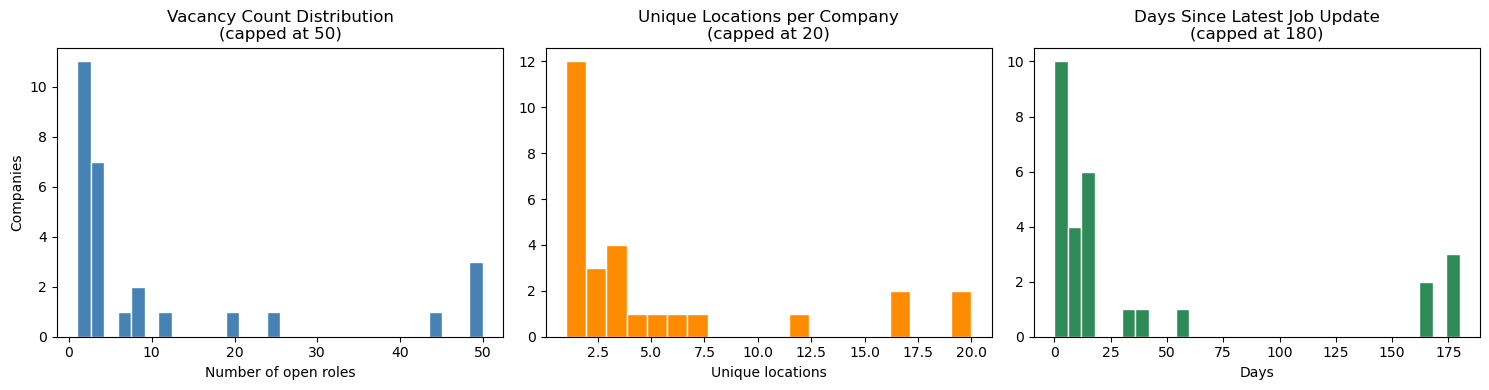

In [29]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 每家公司职位数分布
vacancies = jobs_df.groupby('CompanyNumber').size()
axes[0].hist(vacancies.clip(upper=50), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Vacancy Count Distribution\n(capped at 50)')
axes[0].set_xlabel('Number of open roles')
axes[0].set_ylabel('Companies')

# 独立地点数分布
unique_locs = jobs_df.groupby('CompanyNumber')['location'].nunique()
axes[1].hist(unique_locs.clip(upper=20), bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Unique Locations per Company\n(capped at 20)')
axes[1].set_xlabel('Unique locations')

# 最近更新距今天数
jobs_df['updated_dt'] = pd.to_datetime(jobs_df['updated_at'], utc=True, errors='coerce')
latest_per_company = jobs_df.groupby('CompanyNumber')['updated_dt'].max()
now = pd.Timestamp.now(tz='UTC')
days_since = (now - latest_per_company).dt.days.clip(upper=180)
axes[2].hist(days_since, bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Days Since Latest Job Update\n(capped at 180)')
axes[2].set_xlabel('Days')

plt.tight_layout()
plt.show()

## 7. Step 4 — 聚合成 Growth Signal 特征

每家公司聚合为以下字段：

| 字段 | 说明 |
|------|------|
| `vacancy_count` | 在招职位总数 |
| `unique_titles` | 不重复职位头衔数 |
| `unique_locations` | 不重复地点数 |
| `latest_job_update` | 最近一次职位更新时间 |
| `days_since_update` | 距今多少天 |
| `is_actively_hiring` | 最近 30 天内有更新 |
| `hiring_growth_score` | 0–100 综合招聘增长评分 |

In [23]:
def compute_hiring_signals(jobs_df: pd.DataFrame) -> pd.DataFrame:
    now = datetime.now(tz=timezone.utc)

    def agg(grp):
        dates = pd.to_datetime(grp['updated_at'], utc=True, errors='coerce').dropna()
        latest    = dates.max() if not dates.empty else pd.NaT
        days_since = (now - latest).days if pd.notna(latest) else 999

        vacancy_count    = len(grp)
        unique_titles    = grp['job_title'].nunique()
        unique_locations = (
            grp['location']
            .apply(lambda x: [l.strip() for l in str(x).split('/') if l.strip()])
            .explode().nunique()
        )

        # ── 评分规则（总分上限 100） ──
        score = 0
        # 职位数量
        if vacancy_count >= 20:    score += 35
        elif vacancy_count >= 10:  score += 25
        elif vacancy_count >= 3:   score += 10
        # 地域扩张
        if unique_locations >= 5:  score += 25
        elif unique_locations >= 2:score += 10
        # 职能多样性
        if unique_titles >= 10:    score += 20
        elif unique_titles >= 5:   score += 10
        # 招聘新鲜度
        if days_since <= 7:        score += 20
        elif days_since <= 30:     score += 15
        elif days_since <= 90:     score += 5

        return pd.Series({
            'gh_slug':             grp['gh_slug'].iloc[0],
            'vacancy_count':       vacancy_count,
            'unique_titles':       unique_titles,
            'unique_locations':    unique_locations,
            'latest_job_update':   latest.isoformat() if pd.notna(latest) else None,
            'days_since_update':   days_since,
            'is_actively_hiring':  days_since <= 30,
            'hiring_growth_score': min(score, 100),
        })

    return jobs_df.groupby('CompanyNumber').apply(agg).reset_index()


signals = compute_hiring_signals(jobs_df)
print(f"聚合完成，共 {len(signals):,} 家公司有招聘信号")
signals.head(10)

✓ 聚合完成，共 28 家公司有招聘信号


/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_58318/1626084393.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return jobs_df.groupby('CompanyNumber').apply(agg).reset_index()


,CompanyNumber,gh_slug,vacancy_count,unique_titles,unique_locations,latest_job_update,days_since_update,is_actively_hiring,hiring_growth_score
0,00000371,london,4,4,3,2026-01-08T15:16:30+00:00,164,False,20
1,00006039,general,1,1,1,2026-05-11T17:52:29+00:00,41,False,5
2,00012289,milton,1,1,1,2026-06-09T20:58:44+00:00,12,True,15
3,00012583,guild,11,11,2,2026-06-15T18:09:39+00:00,6,True,75
4,00012592,reflex,3,3,1,2026-06-05T14:00:11+00:00,17,True,25
5,02518238,iris,9,9,5,2026-06-16T20:50:33+00:00,5,True,65
6,02588828,air,45,45,4,2026-06-18T15:10:35+00:00,3,True,85
7,04596546,abc,24,15,21,2026-06-11T09:44:39+00:00,11,True,95
8,06639094,london,4,4,3,2026-01-08T15:16:30+00:00,164,False,20
9,06911340,new,1,1,1,2024-07-24T20:10:07+00:00,697,False,0


In [31]:
# ── 合并回主表（没找到 Greenhouse 的公司填 0） ──
all_cn = master[['CompanyNumber','CompanyName']].copy().astype(str)
signals['CompanyNumber'] = signals['CompanyNumber'].astype(str)

signals_full = all_cn.merge(signals, on='CompanyNumber', how='left')
signals_full['hiring_growth_score'] = signals_full['hiring_growth_score'].fillna(0)
signals_full['gh_found']            = signals_full['gh_slug'].notna()

signals_full.to_csv(SIGNALS_PATH, index=False)
print(f" 完整信号表已保存 → {SIGNALS_PATH}")
print()
print(f"  有 Greenhouse 数据的公司:  {signals_full['gh_found'].sum():,}")
print(f"  无 Greenhouse 数据的公司:  {(~signals_full['gh_found']).sum():,}")
print(f"  正在积极招聘（30天内）:    {signals_full['is_actively_hiring'].sum():,}")
print(f"  hiring_growth_score 均值:  {signals_full['hiring_growth_score'].mean():.1f}")
print()
print("评分分布：")
print(signals_full['hiring_growth_score'].describe().round(1).to_string())

 完整信号表已保存 → ../output/hiring_signals.csv

  有 Greenhouse 数据的公司:  23
  无 Greenhouse 数据的公司:  777
  正在积极招聘（30天内）:    17
  hiring_growth_score 均值:  1.3

评分分布：
count    800.0
mean       1.3
std        9.5
min        0.0
25%        0.0
50%        0.0
75%        0.0
max      100.0


## 8. 招聘增长评分分布

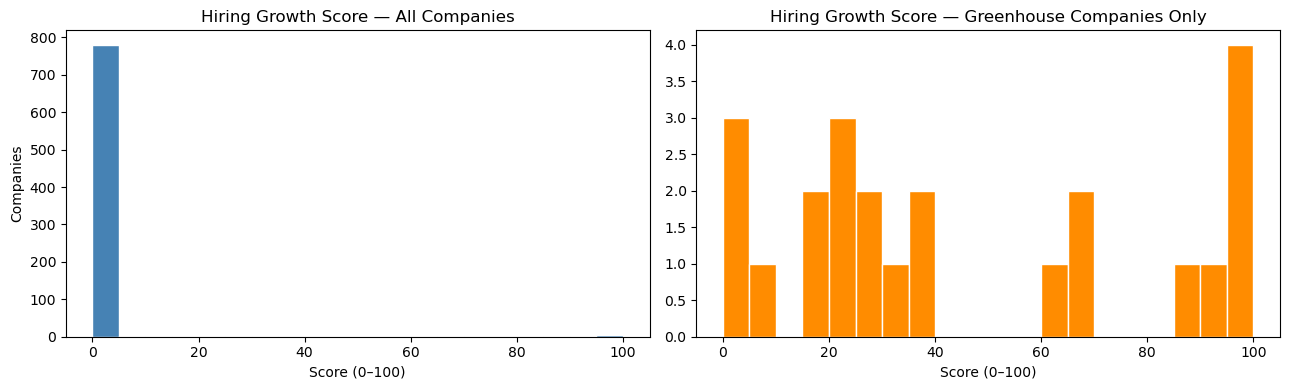

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 全体评分分布（包含 0 分）
axes[0].hist(signals_full['hiring_growth_score'], bins=20,
             color='steelblue', edgecolor='white')
axes[0].set_title('Hiring Growth Score — All Companies')
axes[0].set_xlabel('Score (0–100)')
axes[0].set_ylabel('Companies')

# 仅有 Greenhouse 数据的公司
gh_only = signals_full[signals_full['gh_found']]
axes[1].hist(gh_only['hiring_growth_score'], bins=20,
             color='darkorange', edgecolor='white')
axes[1].set_title('Hiring Growth Score — Greenhouse Companies Only')
axes[1].set_xlabel('Score (0–100)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hiring_score_dist.png', dpi=120)
plt.show()

## 9. 高评分公司预览（Top 20）

In [34]:
top20 = (
    signals_full[signals_full['gh_found']]
    .sort_values('hiring_growth_score', ascending=False)
    .head(20)[['CompanyNumber', 'CompanyName', 'gh_slug', 'vacancy_count',
               'unique_titles', 'unique_locations',
               'days_since_update', 'is_actively_hiring',
               'hiring_growth_score']]
    .reset_index(drop=True)
)
top20

,CompanyNumber,CompanyName,gh_slug,vacancy_count,unique_titles,unique_locations,days_since_update,is_actively_hiring,hiring_growth_score
0,08171950,ORCHARD BLOODSTOCK LIMITED,orchard,53.0,16.0,17.0,3.0,True,100.0
1,13309711,ABACUS FINCH LTD,abacus,65.0,32.0,26.0,4.0,True,100.0
2,11743414,SUPER USEFUL LTD,super,219.0,130.0,12.0,0.0,True,100.0
3,04596546,ABC CHILD'S PLAY LIMITED,abc,24.0,15.0,21.0,11.0,True,95.0
4,12217428,SUNRISE PRACTICE LIMITED,sunrise,19.0,16.0,17.0,3.0,True,90.0
5,02588828,AIR CAT LIMITED,air,45.0,45.0,4.0,3.0,True,85.0
6,02518238,IRIS DESIGN SERVICES LIMITED,iris,9.0,9.0,5.0,5.0,True,65.0
7,14334586,C&C TREE SERVICES LTD,cc,7.0,7.0,6.0,0.0,True,65.0
8,12084232,BLUEPRINT MEDICINES (UK) LTD.,blueprintmedicines,8.0,8.0,7.0,10.0,True,60.0
9,11690230,AG AGRI LTD,ag,3.0,3.0,3.0,12.0,True,35.0


## 10. 下一步：接入 Opportunity Score

`hiring_signals.csv` 已经可以直接和其他信号合并：

```python
# 伪代码示意
opportunity_score = (
    0.35 * hiring_growth_score      # Growth Signal（本 notebook 输出）
  + 0.35 * news_sentiment_score     # News Signal（NewsAPI / GDELT）
  + 0.20 * financial_proxy_score    # Financial Proxy（Companies House 申报行为）
  - 0.10 * risk_penalty             # 风险扣分（董事变更、迟报等）
)
```

**输出文件说明**

| 文件 | 说明 |
|------|------|
| `greenhouse_slug_map.csv` | 公司 → Greenhouse slug 映射，调试用 |
| `greenhouse_jobs_raw.csv` | 每个职位一行，可做 title NLP 细化分析 |
| `hiring_signals.csv` | **主输出**，每家公司一行，含 `hiring_growth_score` |
| `hiring_eda.png` | 数据分布图 |
| `hiring_score_dist.png` | 评分分布图 |